### Notebook used to perform data analysis on the MASSIVE dataset

In [1]:
import sys
sys.path.append("..")
from src.core.dataloader import load_massive_dataset, label_map
from src.core.configuration import load_config, set_seed
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sas


c:\Users\bruno\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = load_config()
set_seed(config["seed"])

In [10]:
df = load_massive_dataset(config,  ["en-US"], config["split_names"])

Using the latest cached version of the dataset since qanastek/MASSIVE couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'en-US' at C:\Users\bruno\.cache\huggingface\datasets\qanastek___massive\en-US\1.0.0\31cdffab94ac97bfe5a394b1e96344c96f0ad847e1d796c7562d8c8b449e22e6 (last modified on Thu May  7 12:33:27 2026).


In [11]:
print(df)

DatasetDict({
    train_set: Dataset({
        features: ['id', 'utt', 'intent', 'locale'],
        num_rows: 11514
    })
    test_set: Dataset({
        features: ['id', 'utt', 'intent', 'locale'],
        num_rows: 2974
    })
    eval_set: Dataset({
        features: ['id', 'utt', 'intent', 'locale'],
        num_rows: 2033
    })
})


In [12]:
num2intent, intent2num = label_map(df["train_set"])

In [13]:
df_train = df["train_set"]

In [14]:
print(df_train)

Dataset({
    features: ['id', 'utt', 'intent', 'locale'],
    num_rows: 11514
})


In [15]:
df_train = pd.DataFrame(df_train)

In [14]:
print(df_train.info())

<class 'pandas.DataFrame'>
RangeIndex: 23028 entries, 0 to 23027
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      23028 non-null  str  
 1   utt     23028 non-null  str  
 2   intent  23028 non-null  int64
 3   locale  23028 non-null  str  
dtypes: int64(1), str(3)
memory usage: 1.7 MB
None


In [15]:
print(df_train.isnull().sum())

id        0
utt       0
intent    0
locale    0
dtype: int64


In [16]:
print(num2intent[4]) # calendar_set is the most commmun intent 
print(num2intent[15]) # whilst a cooking query the least commun

calendar_set
cooking_query


In [25]:
intent_counts = df_train["intent"].value_counts()

intent_table = intent_counts.rename_axis("intent_num").reset_index(name="count")
intent_table["intent_name"] = intent_table["intent_num"].map(num2intent)


intent_table = intent_table[["intent_num", "intent_name", "count"]]

intent_table.to_excel("intent_counts.xlsx", index=False)

In [26]:
def print_random_utterances(df, intent_name, num2intent, n=10, text_col="utt", seed=None):
    # Invert the mapping so we can go from name -> number
    intent2num = {v: k for k, v in num2intent.items()}

    intent_num = intent2num[intent_name]
    subset = df[df["intent"] == intent_num]


    print(f"Intent: {intent_name} (num={intent_num}) — {len(subset)} total\n")
    for i, utt in enumerate(subset[text_col], 1):
        print(f"{i:2d}. {utt}")

In [86]:
print_random_utterances(df_train, "music_dislikeness", num2intent)

Intent: music_dislikeness (num=59) — 14 total

 1. i don't like it
 2. that song in the background is annoying
 3. this song is not very good
 4. do not play this song again
 5. i don't like this song
 6. skip this song
 7. i hate this song please remember that so that i don't hear this song ever again
 8. i hate this song do not play it again
 9. remember that i do not like this music
10. hi google this song is too noisy
11. this song is too length
12. i don't want to hear any more songs of that type
13. i do not enjoy this song
14. that background song is terrible


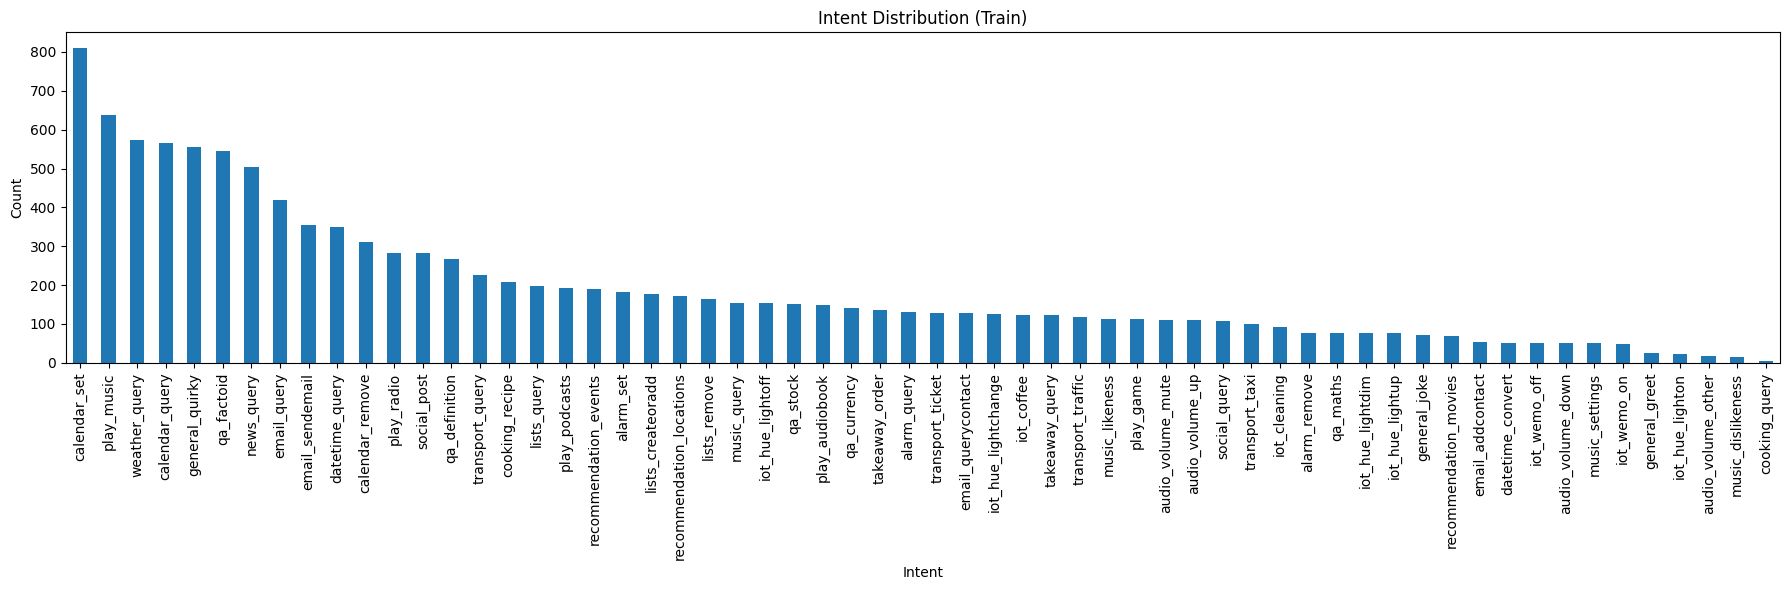

In [16]:
intent_counts = df_train["intent"].value_counts()

fig, ax = plt.subplots(figsize=(18, 6))
intent_counts_named = intent_counts.rename(index=num2intent)
intent_counts_named.sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_xlabel("Intent")
ax.set_ylabel("Count")
ax.set_title("Intent Distribution (Train)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

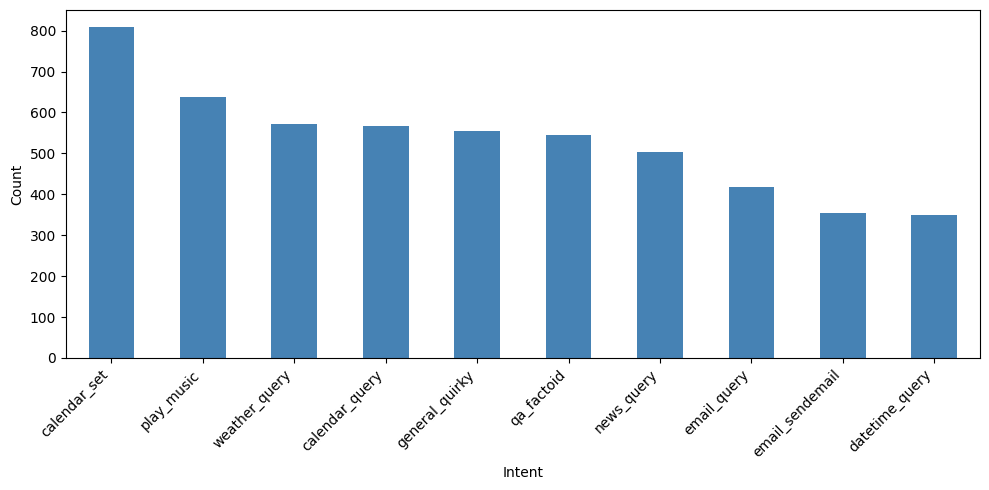

In [17]:
intent_counts = df_train["intent"].value_counts()
intent_counts_named = intent_counts.rename(index=num2intent)
top10 = intent_counts_named.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top10.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Intent")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")
plt.tight_layout()
plt.show()

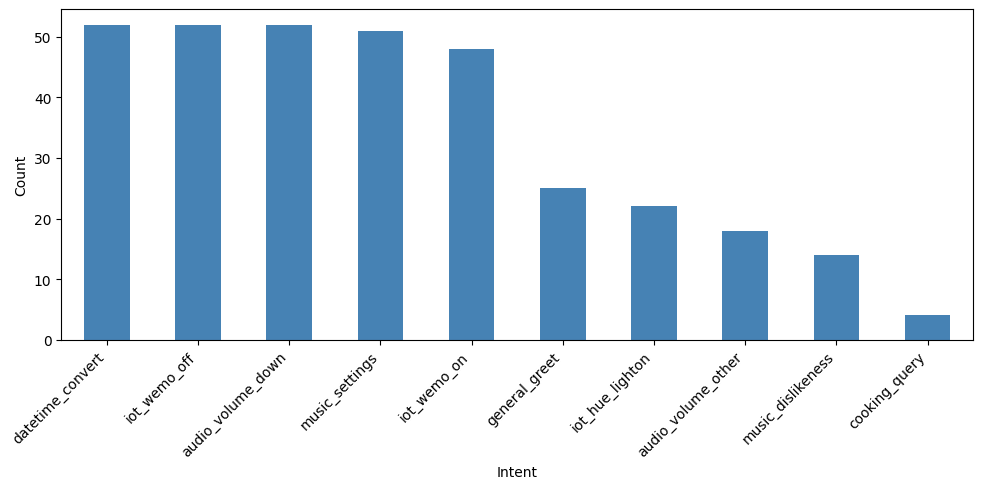

In [18]:
intent_counts = df_train["intent"].value_counts()
intent_counts_named = intent_counts.rename(index=num2intent)
top10 = intent_counts_named.tail(10).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
top10.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Intent")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")
plt.tight_layout()
plt.show()

In [ ]:
# Function to manually assess the translation between the two language and see details and difference
import random
random.seed(41)
array_EN=[]
array_ES=[]
array_intent=[]
name_intent=[]
for i in range (50):
    id = random.choice(df_train["id"].unique())
    array_EN.append(df_train.loc[(df_train["id"] == id) & (df_train["locale"] == "en-US"), "utt"].values[0])
    array_ES.append(df_train.loc[(df_train["id"] == id) & (df_train["locale"] == "es-ES"), "utt"].values[0])
    array_intent.append(num2intent[df_train.loc[(df_train["id"] == id) & (df_train["locale"] == "en-US"), "intent"].values[0]])
    
comparison_df = pd.DataFrame({"English": array_EN, "Spanish": array_ES, "Intent": array_intent})

#Things I see:
# - Names of people are sometimes changed from english to spanish
# - Generally good translations
# - some inconsistencies between translations sometimes  [go to cnncom , ve a mallorca punto com] [what sapp, que sapp] 

In [73]:
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 100)
comparison_df


,English,Spanish,Intent
0,play music radio for me,pon música de radio para mí,play_radio
1,how many people are coming to tonight's dinner,cuántas personas vendrán a la cena de esta noche,calendar_query
2,set the time zone to g. m. t.,fija la zona horaria a g. m. t.,datetime_convert
3,raise living room lights half way,sube las luces del salon hasta la mitad,iot_hue_lightup
4,open pandora and search for a classic rock station,pon cadena dial y busca estacion rock clasico,play_radio
5,where is burmuda triangle,donde esta el triangulo de las bermudas,qa_factoid
6,what sapp,que sapp,email_querycontact
7,repeating event meeting on mondays,evento de reunión recurrente los lunes,calendar_set
8,when you ask it to schedule an appointment that it can email the specific person and provide ava...,cuando le pide que programe una cita puede enviar un correo electrónico a la persona específica ...,qa_factoid
9,put reminder to call pawel tomorrow,pon un recordatorio para llamar a pablo mañana,calendar_set
